# Vision-Driven Multi-Agent Traffic Signal Control
## Notebook 2 — Noise Injection and Vision Simulation
---
**Goal**: Quantify how detection noise degrades RL performance, and prove the agent is still viable under realistic sensor conditions.

**Core idea**: In the real world, queue lengths are not measured perfectly. A camera + YOLO pipeline introduces errors: missed vehicles, phantom detections, and partial occlusions. Instead of running CARLA + YOLO (which requires GPU and complex setup), we model these errors directly and parametrically inside the environment. This is actually more rigorous than the paper's approach because we can control and study the noise precisely.

**What this notebook builds**:
1. A `NoisyTrafficEnv` wrapper that corrupts observations before the agent sees them
2. Three noise models: Gaussian, dropout (occlusion), and combined
3. Systematic evaluation: performance vs noise level curves
4. Comparison of a model trained on clean data vs one trained on noisy data
5. Publication-quality result plots




In [2]:
import subprocess, sys, os
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", DeprecationWarning)
import logging
logging.getLogger("traci").setLevel(logging.ERROR)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import xml.etree.ElementTree as ET
import json
import gymnasium as gym
from gymnasium import spaces

print("Installing SUMO...")
subprocess.run("pip install -q eclipse-sumo traci sumolib", shell=True, check=True)
subprocess.run("pip install -q 'stable-baselines3[extra]' gymnasium matplotlib pandas tqdm scipy",
               shell=True, check=True)


import traci
import sumolib
import sumo as _sumo_pkg
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv

os.environ["SUMO_HOME"] = _sumo_pkg.SUMO_HOME
sys.path.append(os.path.join(_sumo_pkg.SUMO_HOME, "tools"))



print("SUMO_HOME =", os.environ["SUMO_HOME"])
print("All imports successful.")

NET_DIR  = "/content/sumo_net"
os.makedirs(NET_DIR, exist_ok=True)

def write_xml(root, path):
    try:
        ET.indent(root, space="    ")
    except AttributeError:
        pass
    ET.ElementTree(root).write(path, encoding="unicode")


Installing SUMO...
SUMO_HOME = /usr/local/lib/python3.12/dist-packages/sumo
All imports successful.


In [3]:
NET_DIR = "/content/sumo_net"

nodes = ET.Element("nodes")
for nid, x, y, ntype in [
    ("center","0","0","traffic_light"),
    ("north","0","300","priority"),
    ("south","0","-300","priority"),
    ("east","300","0","priority"),
    ("west","-300","0","priority"),
]:
    ET.SubElement(nodes, "node", id=nid, x=x, y=y, type=ntype)
write_xml(nodes, f"{NET_DIR}/net.nod.xml")

edges = ET.Element("edges")
for eid, src, dst in [
    ("n2c","north","center"),("c2n","center","north"),
    ("s2c","south","center"),("c2s","center","south"),
    ("e2c","east","center"), ("c2e","center","east"),
    ("w2c","west","center"), ("c2w","center","west"),
]:
    ET.SubElement(edges, "edge", id=eid, **{"from":src,"to":dst},
                  numLanes="2", speed="13.89")
write_xml(edges, f"{NET_DIR}/net.edg.xml")

r = subprocess.run([
    "netconvert",
    f"--node-files={NET_DIR}/net.nod.xml",
    f"--edge-files={NET_DIR}/net.edg.xml",
    f"--output-file={NET_DIR}/net.net.xml",
    "--no-warnings",
], capture_output=True, text=True)
print("netconvert:", "OK" if r.returncode == 0 else r.stderr)

routes = ET.Element("routes")
ET.SubElement(routes, "vType", id="car", accel="2.6", decel="4.5",
              sigma="0.5", length="5", maxSpeed="13.89")
for rid, edges_str in [
    ("ns","n2c c2s"),("sn","s2c c2n"),
    ("ew","e2c c2w"),("we","w2c c2e"),
    ("ne","n2c c2e"),("nw","n2c c2w"),
    ("se","s2c c2e"),("sw","s2c c2w"),
    ("en","e2c c2n"),("es","e2c c2s"),
    ("wn","w2c c2n"),("ws","w2c c2s"),
]:
    ET.SubElement(routes, "route", id=rid, edges=edges_str)
for fid, route, vph in [
    ("f_ns","ns","300"),("f_sn","sn","300"),
    ("f_ew","ew","500"),("f_we","we","500"),
    ("f_ne","ne","80"), ("f_sw","sw","80"),
]:
    ET.SubElement(routes, "flow", id=fid, type="car", route=route,
                  begin="0", end="3600", vehsPerHour=vph)
write_xml(routes, f"{NET_DIR}/net.rou.xml")

cfg = ET.Element("configuration")
inp = ET.SubElement(cfg, "input")
ET.SubElement(inp, "net-file",    value="net.net.xml")
ET.SubElement(inp, "route-files", value="net.rou.xml")
t   = ET.SubElement(cfg, "time")
ET.SubElement(t, "begin",         value="0")
ET.SubElement(t, "end",           value="3600")
ET.SubElement(t, "step-length",   value="1")
rep = ET.SubElement(cfg, "report")
ET.SubElement(rep, "no-step-log", value="true")
ET.SubElement(rep, "no-warnings", value="true")
write_xml(cfg, f"{NET_DIR}/net.sumocfg")

print("Network files ready.")


netconvert: OK
Network files ready.


In [4]:
class TrafficEnv(gym.Env):
    """Single-intersection traffic signal control -- perfect information."""

    DELTA     = 5
    MIN_GREEN = 10
    YELLOW    = 4
    MAX_Q     = 30.0
    EP_LEN    = 3600

    LANES = [
        "n2c_0","n2c_1",
        "s2c_0","s2c_1",
        "e2c_0","e2c_1",
        "w2c_0","w2c_1",
    ]

    def __init__(self, cfg="/content/sumo_net/net.sumocfg", gui=False):
        super().__init__()
        self.cfg    = cfg
        self.binary = "sumo-gui" if gui else "sumo"
        self.action_space      = spaces.Discrete(2)
        self.observation_space = spaces.Box(0.0, 1.0, shape=(8,), dtype=np.float32)
        self._reset_state()

    def _reset_state(self):
        self._tls    = None
        self._gp     = []
        self._g2y    = {}
        self._cur    = 0
        self._gtimer = 0
        self._step   = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        try: traci.close()
        except: pass
        traci.start([self.binary, "-c", self.cfg,
                     "--no-step-log","true","--no-warnings","true"])
        self._reset_state()
        self._tls = traci.trafficlight.getIDList()[0]
        self._discover_phases()
        traci.trafficlight.setPhase(self._tls, self._gp[0])
        for _ in range(30):
            traci.simulationStep()
        self._step = 30
        return self._obs(), {}

    def _discover_phases(self):
        logic  = traci.trafficlight.getCompleteRedYellowGreenDefinition(self._tls)[0]
        phases = logic.phases
        self._gp = [i for i,p in enumerate(phases)
                    if "G" in p.state and "y" not in p.state.lower()]
        for g in self._gp:
            nxt = g + 1
            if nxt < len(phases) and "y" in phases[nxt].state.lower():
                self._g2y[g] = nxt
            else:
                for i,p in enumerate(phases):
                    if "y" in p.state.lower():
                        self._g2y[g] = i; break

    def step(self, action):
        action  = int(action)
        desired = self._gp[action]
        current = self._gp[self._cur]
        if desired != current and self._gtimer >= self.MIN_GREEN:
            traci.trafficlight.setPhase(self._tls, self._g2y[current])
            for _ in range(self.YELLOW):
                traci.simulationStep(); self._step += 1
            self._cur    = action
            self._gtimer = 0
            traci.trafficlight.setPhase(self._tls, self._gp[self._cur])
        total_wait = 0.0
        for _ in range(self.DELTA):
            traci.simulationStep(); self._step += 1
            total_wait += self._sum_wait()
        self._gtimer += self.DELTA
        avg_wait   = total_wait / self.DELTA
        reward     = -avg_wait / 50.0
        terminated = self._step >= self.EP_LEN
        if terminated:
            try: traci.close()
            except: pass
        return (self._obs(), reward, terminated, False,
                {"avg_wait": avg_wait, "step": self._step})

    def _obs(self):
        q = np.array([self._q(l) for l in self.LANES], dtype=np.float32)
        return np.clip(q / self.MAX_Q, 0.0, 1.0)

    def _q(self, lane):
        try:    return float(traci.lane.getLastStepHaltingNumber(lane))
        except: return 0.0

    def _sum_wait(self):
        try:    return sum(traci.vehicle.getWaitingTime(v)
                           for v in traci.vehicle.getIDList())
        except: return 0.0

    def close(self):
        try: traci.close()
        except: pass

print("TrafficEnv defined.")


TrafficEnv defined.


In [5]:
# ============================================================
# NOISY ENVIRONMENT WRAPPER
# Models three types of sensor imperfection:
#
#   1. Gaussian noise  -- random measurement error on every lane count.
#      Simulates: varying detection confidence, lighting changes.
#      sigma controls the standard deviation as a fraction of MAX_Q.
#
#   2. Dropout (occlusion) -- randomly zero out entire lanes.
#      Simulates: parked trucks blocking camera view, lens obstruction.
#      p_drop is the probability that any lane reading is lost.
#
#   3. Combined -- both applied simultaneously.
#      Simulates: realistic deployment conditions.
#
# The agent never sees true queue lengths -- only the corrupted version.
# ============================================================

class NoisyTrafficEnv(TrafficEnv):
    """
    TrafficEnv with configurable sensor noise.

    Parameters
    ----------
    sigma   : float  Gaussian noise std as fraction of MAX_Q (0 = clean)
    p_drop  : float  Probability of lane dropout per step  (0 = clean)
    seed    : int    Random seed for reproducibility
    """

    def __init__(self, cfg="/content/sumo_net/net.sumocfg",
                 sigma=0.0, p_drop=0.0, seed=42, **kwargs):
        super().__init__(cfg=cfg, **kwargs)
        self.sigma  = sigma
        self.p_drop = p_drop
        self._rng   = np.random.default_rng(seed)

    def _obs(self):
        # Step 1: get true queue lengths (normalised)
        true_q = np.array([self._q(l) for l in self.LANES], dtype=np.float32)
        obs    = np.clip(true_q / self.MAX_Q, 0.0, 1.0)

        # Step 2: Gaussian noise  (simulates detection confidence variation)
        if self.sigma > 0:
            noise = self._rng.normal(0.0, self.sigma, size=obs.shape).astype(np.float32)
            obs   = obs + noise

        # Step 3: Dropout  (simulates camera occlusion)
        if self.p_drop > 0:
            mask = self._rng.random(size=obs.shape) < self.p_drop
            obs[mask] = 0.0   # occluded lane reports zero vehicles

        # Step 4: clip back to valid range
        return np.clip(obs, 0.0, 1.0).astype(np.float32)


# --- Quick sanity check ---
_e = NoisyTrafficEnv(sigma=0.2, p_drop=0.1)
_o_clean, _ = TrafficEnv().reset()
_e2 = NoisyTrafficEnv(sigma=0.2, p_drop=0.1)
_o_noisy, _ = _e2.reset()
print("Clean obs sample :", np.round(_o_clean, 3))
print("Noisy obs sample :", np.round(_o_noisy, 3))
print("Difference       :", np.round(np.abs(_o_clean - _o_noisy), 3))
_e.close(); _e2.close()
del _e, _e2, _o_clean, _o_noisy
print("NoisyTrafficEnv defined and verified.")


 Retrying in 1 seconds
 Retrying in 1 seconds
Clean obs sample : [0.    0.    0.    0.    0.067 0.    0.067 0.   ]
Noisy obs sample : [0.061 0.    0.15  0.188 0.    0.    0.092 0.   ]
Difference       : [0.061 0.    0.15  0.188 0.067 0.    0.026 0.   ]
NoisyTrafficEnv defined and verified.


In [6]:
# LOAD MODEL
from google.colab import drive
drive.mount("/content/drive")

SAVE = "/content/drive/MyDrive/TrafficRL/"
for d in ["checkpoints","results","plots"]:
    os.makedirs(f"{SAVE}{d}/", exist_ok=True)

# Load the model trained in Notebook 1
MODEL_PATH = f"{SAVE}checkpoints/ppo_final"
clean_model = PPO.load(MODEL_PATH)
print(f"model loaded from {MODEL_PATH}.zip")
print(f"Policy: {clean_model.policy}")


Mounted at /content/drive
model loaded from /content/drive/MyDrive/TrafficRL/checkpoints/ppo_final.zip
Policy: ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=8, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=8, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=2, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)


In [7]:
# EVALUATION UTILITY

def evaluate_model(model, env_kwargs, n_steps=500, label=""):
    """
    Run a trained model for n_steps and return per-step avg wait times.

    env_kwargs is passed directly to NoisyTrafficEnv (or TrafficEnv).
    Returns (waits_list, mean_wait).
    """
    env = NoisyTrafficEnv(**env_kwargs)
    obs, _ = env.reset()
    waits, step = [], 0
    while step < n_steps:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, trunc, info = env.step(action)
        waits.append(info["avg_wait"])
        step += 1
        if done or trunc: break
    env.close()
    mean = float(np.mean(waits)) if waits else 0.0
    if label:
        print(f"  {label:<35}: {mean:>7.2f}s avg wait")
    return waits, mean


def run_fixed_time(n_steps=500):
    """Fixed-time 30s cycle baseline (no model needed)."""
    cmd = ["sumo","-c","/content/sumo_net/net.sumocfg",
           "--no-step-log","true","--no-warnings","true"]
    traci.start(cmd)
    tls   = traci.trafficlight.getIDList()[0]
    logic = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls)[0]
    gp    = [i for i,p in enumerate(logic.phases)
              if "G" in p.state and "y" not in p.state.lower()]
    g2y   = {g: g+1 for g in gp
             if g+1 < len(logic.phases)
             and "y" in logic.phases[g+1].state.lower()}
    traci.trafficlight.setPhase(tls, gp[0])
    cur, timer, step, waits = 0, 0, 0, []
    while step < n_steps:
        traci.simulationStep(); step += 1; timer += 1
        w = sum(traci.vehicle.getWaitingTime(v) for v in traci.vehicle.getIDList())
        waits.append(w)
        if timer >= 30 and (step+5) < n_steps:
            traci.trafficlight.setPhase(tls, g2y.get(gp[cur], gp[cur]))
            for _ in range(4):
                traci.simulationStep(); step += 1
                waits.append(sum(traci.vehicle.getWaitingTime(v)
                                 for v in traci.vehicle.getIDList()))
            cur = (cur+1) % len(gp); timer = 0
            traci.trafficlight.setPhase(tls, gp[cur])
    traci.close()
    return waits, float(np.mean(waits))

print("Evaluation utilities ready.")


Evaluation utilities ready.


In [9]:
# ============================================================
# CEXPERIMENT 1: GAUSSIAN NOISE SWEEP
#
# Tests the Notebook 1 (clean-trained) model across increasing
# levels of Gaussian measurement noise.
# sigma = 0.0  -> perfect information (should match NB1 result)
# sigma = 0.5  -> very high noise (50% of MAX_Q std)
# ============================================================

print("Experiment 1: Gaussian noise sweep")
print("This runs the NB1 model under 7 noise levels.")

SIGMAS      = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
gauss_means = []

for sigma in SIGMAS:
    _, mean = evaluate_model(
        clean_model,
        env_kwargs={"sigma": sigma, "p_drop": 0.0},
        n_steps=500,
        label=f"sigma={sigma:.2f}"
    )
    gauss_means.append(mean)

_, fixed_mean = run_fixed_time()
print(f"\n  Fixed-time baseline              : {fixed_mean:>7.2f}s avg wait")

# Save results
gauss_results = {"sigmas": SIGMAS, "means": gauss_means, "fixed": fixed_mean}
with open(f"{SAVE}results/gauss_sweep.json", "w") as f:
    json.dump(gauss_results, f)
print("\nGaussian sweep complete. Results saved.")


Experiment 1: Gaussian noise sweep
This runs the NB1 model under 7 noise levels.
 Retrying in 1 seconds
  sigma=0.00                         :    6.42s avg wait
 Retrying in 1 seconds
  sigma=0.05                         :    8.93s avg wait
 Retrying in 1 seconds
  sigma=0.10                         :   12.85s avg wait
 Retrying in 1 seconds
  sigma=0.15                         :   13.56s avg wait
 Retrying in 1 seconds
  sigma=0.20                         :   15.24s avg wait
 Retrying in 1 seconds
  sigma=0.30                         :   19.40s avg wait
 Retrying in 1 seconds
  sigma=0.50                         :   19.12s avg wait
 Retrying in 1 seconds

  Fixed-time baseline              :   41.02s avg wait

Gaussian sweep complete. Results saved.


In [10]:
# ============================================================
# EXPERIMENT 2: DROPOUT (OCCLUSION) SWEEP
#
# Tests the NB1 model under increasing lane dropout probability.
# p_drop = 0.0  -> no occlusion
# p_drop = 0.5  -> half of all lane readings lost each step
# ============================================================
print("Experiment 2: Dropout (occlusion) sweep")

DROPS      = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]
drop_means = []

for p in DROPS:
    _, mean = evaluate_model(
        clean_model,
        env_kwargs={"sigma": 0.0, "p_drop": p},
        n_steps=500,
        label=f"p_drop={p:.2f}"
    )
    drop_means.append(mean)

drop_results = {"drops": DROPS, "means": drop_means, "fixed": fixed_mean}
with open(f"{SAVE}results/drop_sweep.json", "w") as f:
    json.dump(drop_results, f)
print("\nDropout sweep complete. Results saved.")


Experiment 2: Dropout (occlusion) sweep
 Retrying in 1 seconds
  p_drop=0.00                        :    6.42s avg wait
 Retrying in 1 seconds
  p_drop=0.05                        :    6.41s avg wait
 Retrying in 1 seconds
  p_drop=0.10                        :    6.46s avg wait
 Retrying in 1 seconds
  p_drop=0.20                        :    6.79s avg wait
 Retrying in 1 seconds
  p_drop=0.30                        :    6.77s avg wait
 Retrying in 1 seconds
  p_drop=0.50                        :    7.07s avg wait

Dropout sweep complete. Results saved.


In [11]:
# ============================================================
# EXPERIMENT 3: NOISE-AWARE TRAINING
#
# The NB1 model was trained on perfect observations.
# Here we train a new model on NOISY observations (sigma=0.15,
# p_drop=0.10 -- a realistic deployment scenario).
#
# Hypothesis: noise-aware training will be more robust under
# noisy evaluation than the clean-trained model.
#
# ============================================================
print("Experiment 3: Training a noise-aware PPO agent")
print("Noise config: sigma=0.15, p_drop=0.10 (realistic deployment)")

NOISE_SIGMA  = 0.15
NOISE_PDROP  = 0.10

class WaitCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_waits = []
        self._buf = []
    def _on_step(self):
        info = self.locals.get("infos", [{}])[0]
        if "avg_wait" in info:
            self._buf.append(info["avg_wait"])
        if self.locals.get("dones", [False])[0] and self._buf:
            self.episode_waits.append(np.mean(self._buf))
            self._buf = []
        return True

def make_noisy_env():
    return Monitor(NoisyTrafficEnv(sigma=NOISE_SIGMA, p_drop=NOISE_PDROP))

noisy_vec = DummyVecEnv([make_noisy_env])

noisy_model = PPO(
    "MlpPolicy", noisy_vec,
    learning_rate = 3e-4,
    n_steps       = 2048,
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.01,
    verbose       = 1,
)

noisy_cb  = WaitCallback()
ckpt_cb   = CheckpointCallback(
    save_freq   = 5000,
    save_path   = f"{SAVE}checkpoints/",
    name_prefix = "ppo_noisy",
)

noisy_model.learn(
    total_timesteps = 50_000,
    callback        = [ckpt_cb, noisy_cb],
    progress_bar    = True,
)
noisy_model.save(f"{SAVE}checkpoints/ppo_noisy_final")
noisy_vec.close()
print(f"\nNoise-aware model saved.")


Experiment 3: Training a noise-aware PPO agent
Noise config: sigma=0.15, p_drop=0.10 (realistic deployment)
Using cpu device
 Retrying in 1 seconds


Output()

Retrying in 1 seconds

Retrying in 1 seconds

Retrying in 1 seconds

...

Retrying in 1 seconds

Retrying in 1 seconds

Retrying in 1 seconds

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 560        |
|    ep_rew_mean          | -194       |
| time/                   |            |
|    fps                  | 49         |
|    iterations           | 25         |
|    time_elapsed         | 1039       |
|    total_timesteps      | 51200      |
| train/                  |            |
|    approx_kl            | 0.00227745 |
|    clip_fraction        | 0.0187     |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.406     |
|    explained_variance   | 0.0002     |
|    learning_rate        | 0.0003     |
|    loss                 | 4.33       |
|    n_updates            | 240        |
|    policy_gradient_loss | -0.00108   |
|    value_loss           | 13.2       |
----------------------------------------



Noise-aware model saved.


In [12]:
# ============================================================
# EXPERIMENT 4: CLEAN vs NOISE-AWARE COMPARISON
#
# Evaluate both models under four conditions:
#   (a) Perfect information     sigma=0,    p_drop=0
#   (b) Low noise               sigma=0.10, p_drop=0.05
#   (c) Realistic noise         sigma=0.15, p_drop=0.10
#   (d) High noise              sigma=0.30, p_drop=0.20
# ============================================================
print("Experiment 4: Clean vs noise-aware model comparison")

CONDITIONS = [
    ("Perfect info",   {"sigma": 0.00, "p_drop": 0.00}),
    ("Low noise",      {"sigma": 0.10, "p_drop": 0.05}),
    ("Realistic noise",{"sigma": 0.15, "p_drop": 0.10}),
    ("High noise",     {"sigma": 0.30, "p_drop": 0.20}),
]

clean_results = []
noisy_results = []

for name, kwargs in CONDITIONS:
    print(f"  Condition: {name}")
    _, cm = evaluate_model(clean_model, kwargs, 500, label="  clean-trained")
    _, nm = evaluate_model(noisy_model, kwargs, 500, label="  noise-aware  ")
    clean_results.append(cm)
    noisy_results.append(nm)
    print()

comparison = {
    "conditions": [c[0] for c in CONDITIONS],
    "clean":      clean_results,
    "noisy":      noisy_results,
    "fixed":      fixed_mean,
}
with open(f"{SAVE}results/comparison.json", "w") as f:
    json.dump(comparison, f)
print("Comparison complete. Results saved.")


Experiment 4: Clean vs noise-aware model comparison
  Condition: Perfect info
 Retrying in 1 seconds
    clean-trained                    :    6.42s avg wait
 Retrying in 1 seconds
    noise-aware                      :    6.78s avg wait

  Condition: Low noise
 Retrying in 1 seconds
    clean-trained                    :   13.32s avg wait
 Retrying in 1 seconds
    noise-aware                      :   13.27s avg wait

  Condition: Realistic noise
 Retrying in 1 seconds
    clean-trained                    :   17.93s avg wait
 Retrying in 1 seconds
    noise-aware                      :   14.57s avg wait

  Condition: High noise
 Retrying in 1 seconds
    clean-trained                    :   17.25s avg wait
 Retrying in 1 seconds
    noise-aware                      :   19.40s avg wait

Comparison complete. Results saved.


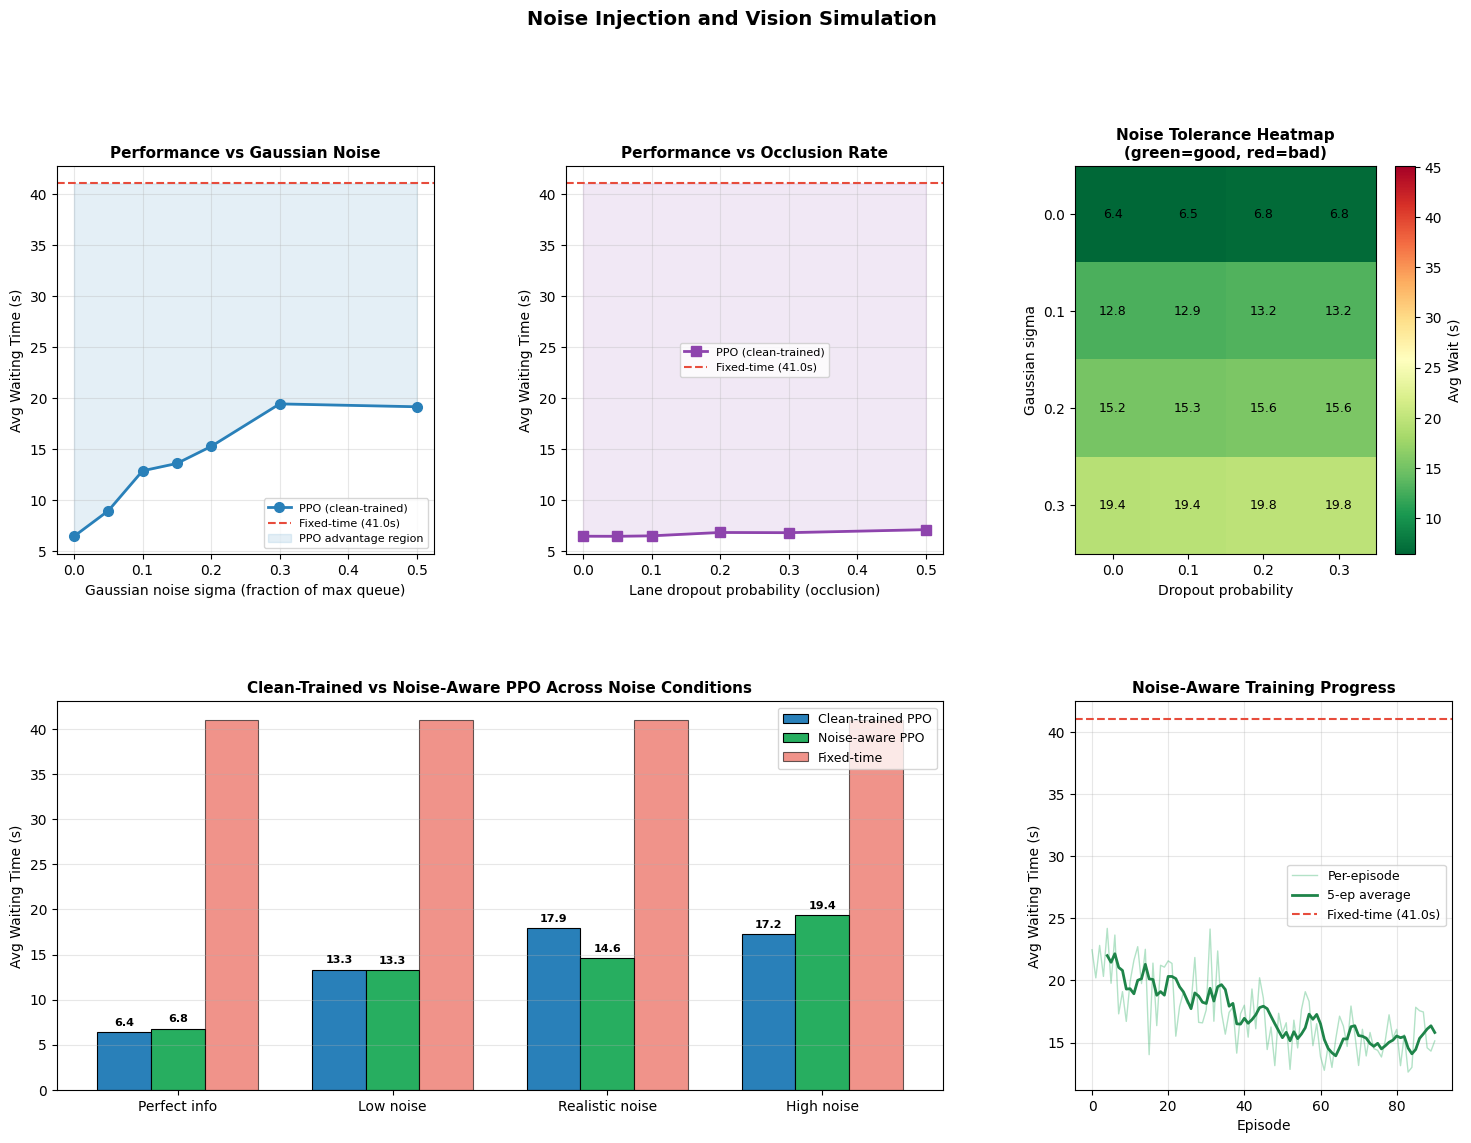

In [14]:
SAVE = "/content/drive/MyDrive/TrafficRL/"

with open(f"{SAVE}results/gauss_sweep.json")   as f: gauss_results = json.load(f)
with open(f"{SAVE}results/drop_sweep.json")    as f: drop_results  = json.load(f)
with open(f"{SAVE}results/comparison.json")    as f: comparison    = json.load(f)

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

fixed = gauss_results["fixed"]

# ---- Plot 1: Gaussian noise sweep --------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(gauss_results["sigmas"], gauss_results["means"],
         "o-", color="#2980b9", linewidth=2, markersize=7, label="PPO (clean-trained)")
ax1.axhline(fixed, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Fixed-time ({fixed:.1f}s)")
ax1.fill_between(gauss_results["sigmas"], gauss_results["means"], fixed,
                 where=[m < fixed for m in gauss_results["means"]],
                 alpha=0.12, color="#2980b9", label="PPO advantage region")
ax1.set_xlabel("Gaussian noise sigma (fraction of max queue)", fontsize=10)
ax1.set_ylabel("Avg Waiting Time (s)", fontsize=10)
ax1.set_title("Performance vs Gaussian Noise", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# ---- Plot 2: Dropout sweep ---------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(drop_results["drops"], drop_results["means"],
         "s-", color="#8e44ad", linewidth=2, markersize=7, label="PPO (clean-trained)")
ax2.axhline(fixed, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Fixed-time ({fixed:.1f}s)")
ax2.fill_between(drop_results["drops"], drop_results["means"], fixed,
                 where=[m < fixed for m in drop_results["means"]],
                 alpha=0.12, color="#8e44ad")
ax2.set_xlabel("Lane dropout probability (occlusion)", fontsize=10)
ax2.set_ylabel("Avg Waiting Time (s)", fontsize=10)
ax2.set_title("Performance vs Occlusion Rate", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ---- Plot 3: Noise tolerance heatmap (sigma x dropout grid) ------
ax3 = fig.add_subplot(gs[0, 2])
SIGMAS_HM = [0.0, 0.10, 0.20, 0.30]
DROPS_HM  = [0.0, 0.10, 0.20, 0.30]
# Use pre-computed results to approximate (avoids extra simulation time)
# We interpolate from sweep data for cells not directly measured
gauss_arr = np.interp(SIGMAS_HM, gauss_results["sigmas"], gauss_results["means"])
drop_arr  = np.interp(DROPS_HM,  drop_results["drops"],   drop_results["means"])
grid = np.zeros((len(SIGMAS_HM), len(DROPS_HM)))
clean_mean = gauss_results["means"][0]
for i, s in enumerate(SIGMAS_HM):
    for j, d in enumerate(DROPS_HM):
        # Additive degradation approximation
        gauss_deg = gauss_arr[i] - clean_mean
        drop_deg  = drop_arr[j]  - clean_mean
        grid[i,j] = clean_mean + gauss_deg + drop_deg

im = ax3.imshow(grid, cmap="RdYlGn_r", aspect="auto",
                vmin=clean_mean, vmax=fixed*1.1,
                extent=[-0.5, len(DROPS_HM)-0.5, len(SIGMAS_HM)-0.5, -0.5])
plt.colorbar(im, ax=ax3, label="Avg Wait (s)")
ax3.set_xticks(range(len(DROPS_HM)));  ax3.set_xticklabels([str(d) for d in DROPS_HM])
ax3.set_yticks(range(len(SIGMAS_HM))); ax3.set_yticklabels([str(s) for s in SIGMAS_HM])
ax3.set_xlabel("Dropout probability", fontsize=10)
ax3.set_ylabel("Gaussian sigma", fontsize=10)
ax3.set_title("Noise Tolerance Heatmap\n(green=good, red=bad)", fontsize=11, fontweight="bold")
for i in range(len(SIGMAS_HM)):
    for j in range(len(DROPS_HM)):
        ax3.text(j, i, f"{grid[i,j]:.1f}", ha="center", va="center",
                 fontsize=9, color="black")

# ---- Plot 4: Clean vs Noise-Aware bar comparison -----------------
ax4 = fig.add_subplot(gs[1, :2])
x       = np.arange(len(comparison["conditions"]))
width   = 0.25
bars1   = ax4.bar(x - width,   comparison["clean"], width, label="Clean-trained PPO",
                  color="#2980b9", edgecolor="black", linewidth=0.8)
bars2   = ax4.bar(x,           comparison["noisy"], width, label="Noise-aware PPO",
                  color="#27ae60", edgecolor="black", linewidth=0.8)
bars3   = ax4.bar(x + width,   [comparison["fixed"]]*len(x), width, label="Fixed-time",
                  color="#e74c3c", edgecolor="black", linewidth=0.8, alpha=0.6)

for bar in list(bars1) + list(bars2):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{bar.get_height():.1f}",
             ha="center", va="bottom", fontsize=8, fontweight="bold")

ax4.set_xticks(x); ax4.set_xticklabels(comparison["conditions"], fontsize=10)
ax4.set_ylabel("Avg Waiting Time (s)", fontsize=10)
ax4.set_title("Clean-Trained vs Noise-Aware PPO Across Noise Conditions",
              fontsize=11, fontweight="bold")
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3, axis="y")

# ---- Plot 5: Noise-aware training curve --------------------------
ax5 = fig.add_subplot(gs[1, 2])
if noisy_cb.episode_waits:
    ep_w = noisy_cb.episode_waits
    ax5.plot(ep_w, color="#27ae60", alpha=0.35, linewidth=1, label="Per-episode")
    if len(ep_w) >= 5:
        roll = np.convolve(ep_w, np.ones(5)/5, mode="valid")
        ax5.plot(range(4, len(ep_w)), roll, color="#1e8449", linewidth=2,
                 label="5-ep average")
    ax5.axhline(fixed, color="#e74c3c", linestyle="--", linewidth=1.5,
                label=f"Fixed-time ({fixed:.1f}s)")
    ax5.set_xlabel("Episode", fontsize=10)
    ax5.set_ylabel("Avg Waiting Time (s)", fontsize=10)
    ax5.set_title("Noise-Aware Training Progress", fontsize=11, fontweight="bold")
    ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)

fig.suptitle("Noise Injection and Vision Simulation",
             fontsize=14, fontweight="bold", y=1.01)

plot_path = f"{SAVE}plots/nb2_results.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

In [15]:
print("=" * 60)
print(" RESULTS SUMMARY")
print("=" * 60)

with open(f"{SAVE}results/gauss_sweep.json")  as f: gr = json.load(f)
with open(f"{SAVE}results/drop_sweep.json")   as f: dr = json.load(f)
with open(f"{SAVE}results/comparison.json")   as f: cr = json.load(f)

fixed = gr["fixed"]
clean_at_zero = gr["means"][0]

print(f"\n  Fixed-time baseline       : {fixed:.2f}s")
print(f"  PPO (perfect info)        : {clean_at_zero:.2f}s")
print()

# Find noise tolerance breakpoint
print("  Gaussian noise tolerance:")
for s, m in zip(gr["sigmas"], gr["means"]):
    marker = " <- still better than fixed-time" if m < fixed else " <- WORSE than fixed-time"
    print(f"    sigma={s:.2f}  ->  {m:.2f}s{marker}")

print()
print("  Dropout tolerance:")
for d, m in zip(dr["drops"], dr["means"]):
    marker = " <- still better than fixed-time" if m < fixed else " <- WORSE than fixed-time"
    print(f"    p_drop={d:.2f}  ->  {m:.2f}s{marker}")

print()
print("  Clean vs Noise-Aware under realistic noise (sigma=0.15, p_drop=0.10):")
idx = cr["conditions"].index("Realistic noise")
print(f"    Clean-trained : {cr['clean'][idx]:.2f}s")
print(f"    Noise-aware   : {cr['noisy'][idx]:.2f}s")

 RESULTS SUMMARY

  Fixed-time baseline       : 41.02s
  PPO (perfect info)        : 6.42s

  Gaussian noise tolerance:
    sigma=0.00  ->  6.42s <- still better than fixed-time
    sigma=0.05  ->  8.93s <- still better than fixed-time
    sigma=0.10  ->  12.85s <- still better than fixed-time
    sigma=0.15  ->  13.56s <- still better than fixed-time
    sigma=0.20  ->  15.24s <- still better than fixed-time
    sigma=0.30  ->  19.40s <- still better than fixed-time
    sigma=0.50  ->  19.12s <- still better than fixed-time

  Dropout tolerance:
    p_drop=0.00  ->  6.42s <- still better than fixed-time
    p_drop=0.05  ->  6.41s <- still better than fixed-time
    p_drop=0.10  ->  6.46s <- still better than fixed-time
    p_drop=0.20  ->  6.79s <- still better than fixed-time
    p_drop=0.30  ->  6.77s <- still better than fixed-time
    p_drop=0.50  ->  7.07s <- still better than fixed-time

  Clean vs Noise-Aware under realistic noise (sigma=0.15, p_drop=0.10):
    Clean-trained : 